# Hipotesis 4: Pases progresivos o verticales

Paso a paso: medimos proporcion de pases progresivos
y relacion con ocasiones/goles.

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [8]:
events_path = Path("D:\\CIENCIA DE DATOS\\PROYECTO_STATSBOMB_V2\\data\\processed\\events\\events_fact.parquet")
matches_path = Path("D:\\CIENCIA DE DATOS\\PROYECTO_STATSBOMB_V2\\data\\processed\\matches\\matches_fact.parquet")
events = pd.read_parquet(events_path)
matches = pd.read_parquet(matches_path)
events.head()

,event_id,match_id,index,period,timestamp,minute,second,event_type_id,event_type_name,team_id,...,possession_team_id,play_pattern_id,play_pattern_name,duration,under_pressure,related_events,x,y,end_x,end_y
0,0b483cd2-1d36-49a0-85c2-149a9de553df,7298,1,1,00:00:00.000,0,0,35,Starting XI,746,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
1,2c873afb-73bb-48a1-9fd5-bfe1400b4a83,7298,2,1,00:00:00.000,0,0,35,Starting XI,971,...,746,1,Regular Play,0.00,None,NaN,NaN,NaN,NaN,NaN
2,040940a1-5972-431e-b6ac-e723edd8e7c2,7298,3,1,00:00:00.000,0,0,18,Half Start,746,...,746,1,Regular Play,7.96,None,"[""5ba286bd-c397-4ac4-b12f-6bace943afce""]",NaN,NaN,NaN,NaN
3,5ba286bd-c397-4ac4-b12f-6bace943afce,7298,4,1,00:00:00.000,0,0,18,Half Start,971,...,746,1,Regular Play,8.16,None,"[""040940a1-5972-431e-b6ac-e723edd8e7c2""]",NaN,NaN,NaN,NaN
4,2a456ec2-352c-499b-b5cc-e68bf84c7e9a,7298,5,1,00:00:00.100,0,0,30,Pass,971,...,971,9,From Kick Off,0.00,None,"[""483b7286-e75e-4191-80be-ac93bfed1473""]",61.0,40.0,63.0,37.0


In [9]:
# Paso 1: filtrar pases (event_type_name == 'Pass')
passes = events[events["event_type_name"] == "Pass"].copy()
passes = passes.dropna(subset=["x", "y", "end_x", "end_y", "match_id", "team_id"])

passes["dx"] = passes["end_x"] - passes["x"]
passes["dy"] = passes["end_y"] - passes["y"]
passes["distance"] = (passes["dx"] ** 2 + passes["dy"] ** 2) ** 0.5
passes["angle_deg"] = np.degrees(np.arctan2(passes["dy"].abs(), passes["dx"].abs()))

# Nota: suponemos que el avance hacia el arco rival es dx > 0
passes["vertical"] = (passes["dx"] > 0) & (passes["angle_deg"] <= 20) & (passes["distance"] >= 10)
passes["horizontal"] = passes["angle_deg"] >= 70
passes.head()

,event_id,match_id,index,period,timestamp,minute,second,event_type_id,event_type_name,team_id,...,x,y,end_x,end_y,dx,dy,distance,angle_deg,vertical,horizontal
4,2a456ec2-352c-499b-b5cc-e68bf84c7e9a,7298,5,1,00:00:00.100,0,0,30,Pass,971,...,61.0,40.0,63.0,37.0,2.0,-3.0,3.605551,56.309932,False,False
8,38023613-6b26-44e2-a0f8-9aab9960d2ff,7298,9,1,00:00:00.500,0,0,30,Pass,971,...,69.0,33.0,84.0,5.0,15.0,-28.0,31.764760,61.821410,False,False
14,b8c43bec-de04-4cbb-87b5-f0c454a6fa94,7298,15,1,00:00:25.873,0,25,30,Pass,746,...,6.0,43.0,59.0,69.0,53.0,26.0,59.033889,26.131001,False,False
16,fa7be948-c79a-4f6e-a0b4-73808797ce53,7298,17,1,00:00:28.460,0,28,30,Pass,971,...,62.0,12.0,80.0,10.0,18.0,-2.0,18.110770,6.340192,True,False
19,7cc1c0c6-2c01-44d7-84dc-af3174363676,7298,20,1,00:00:29.633,0,29,30,Pass,746,...,41.0,71.0,43.0,73.0,2.0,2.0,2.828427,45.000000,False,False


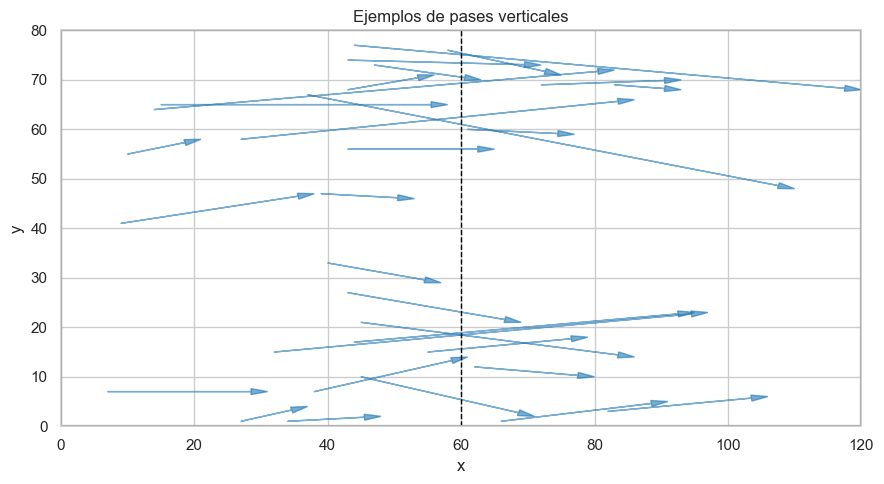

In [12]:
# Paso 1b: campo de futbol con ejemplos de pases verticales
fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

sample_vertical = passes[passes["vertical"]].dropna(subset=["x", "y", "end_x", "end_y"]).head(30)

plt.figure(figsize=(9, 5))
plt.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
plt.plot([60, 60], [0, 80], color="black", linestyle="--", linewidth=1)

for _, row in sample_vertical.iterrows():
    plt.arrow(
        row["x"],
        row["y"],
        row["end_x"] - row["x"],
        row["end_y"] - row["y"],
        head_width=1.2,
        head_length=2.5,
        length_includes_head=True,
        color="#1f77b4",
        alpha=0.6,
    )

plt.title("Ejemplos de pases verticales")
plt.xlim(0, 120)
plt.ylim(0, 80)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig(fig_dir / "h4_pases_verticales_campo.png", dpi=160)
plt.show()

In [13]:
# Paso 2: agregar proporciones por equipo y partido
agg = (
    passes.groupby(["match_id", "team_id"])
    .agg(
        pases_total=("event_id", "count"),
        vertical_pct=("vertical", "mean"),
        horizontal_pct=("horizontal", "mean"),
    )
    .reset_index()
)
agg.head()

# Paso 3: unir con goles por equipo
home = matches[["match_id", "home_team_id", "home_score", "away_score"]].copy()
home["team_id"] = home["home_team_id"]
home["goles_favor"] = home["home_score"]
away = matches[["match_id", "away_team_id", "home_score", "away_score"]].copy()
away["team_id"] = away["away_team_id"]
away["goles_favor"] = away["away_score"]

goals = pd.concat(
    [
        home[["match_id", "team_id", "goles_favor"]],
        away[["match_id", "team_id", "goles_favor"]],
    ],
    ignore_index=True,
)

df = agg.merge(goals, on=["match_id", "team_id"], how="left")
df[["vertical_pct", "horizontal_pct", "goles_favor"]].corr()

,vertical_pct,horizontal_pct,goles_favor
vertical_pct,1.000000,-0.789999,-0.219681
horizontal_pct,-0.789999,1.000000,0.165365
goles_favor,-0.219681,0.165365,1.000000


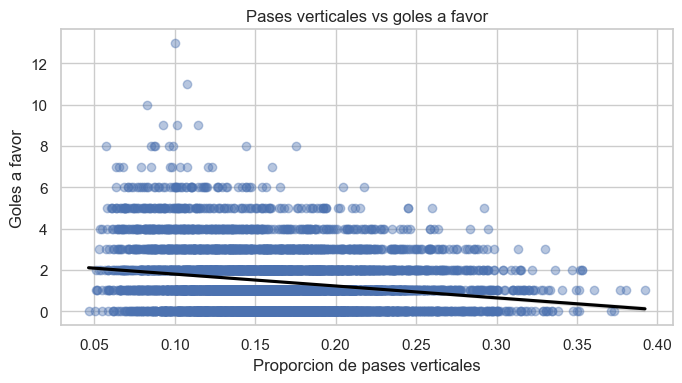

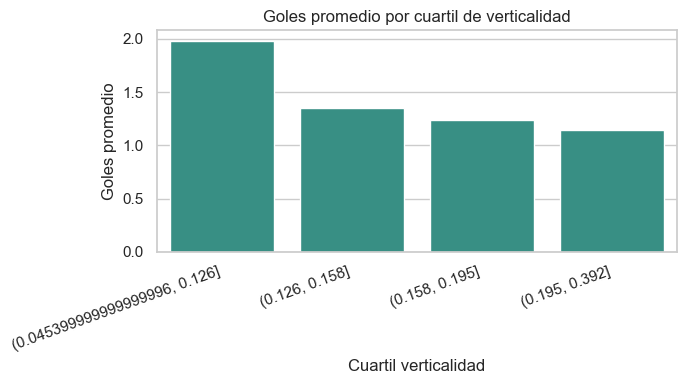

In [14]:
# Paso 4: graficos de relacion verticalidad y goles
fig_dir = Path("docs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
sns.regplot(data=df, x="vertical_pct", y="goles_favor", scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
plt.title("Pases verticales vs goles a favor")
plt.xlabel("Proporcion de pases verticales")
plt.ylabel("Goles a favor")
plt.tight_layout()
plt.savefig(fig_dir / "h4_vertical_scatter.png", dpi=160)
plt.show()

# Paso 5: goles promedio por cuartil de verticalidad
bins = pd.qcut(df["vertical_pct"], q=4, duplicates="drop")
summary = df.groupby(bins)["goles_favor"].mean().reset_index()
summary.columns = ["verticalidad_cuartil", "goles_promedio"]

plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x="verticalidad_cuartil", y="goles_promedio", color="#2a9d8f")
plt.title("Goles promedio por cuartil de verticalidad")
plt.xlabel("Cuartil verticalidad")
plt.ylabel("Goles promedio")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "h4_vertical_bins.png", dpi=160)
plt.show()